# DA301:  Advanced Analytics for Organisational Impact
## Assignment 3: Turtle Games
### Evie Clarke

## Import necessary packages:

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier  
import math
from sklearn import tree
import warnings

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

## Load and Explore the data

In [2]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv('turtle_reviews.csv')

# View the DataFrame.
reviews.head(2)

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.3,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.3,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...


In [3]:
# Check for duplicates
reviews.duplicated().sum()

np.int64(0)

In [4]:
# Determine if there are any missing values and column data types
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [5]:
# Return basic descriptive statistics
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


The following characteristics of data are important to note:
- This dataset contains 2,000 rows of data in 11 columns.
- There are no null or missing values in the data.

## Clean the data

In [6]:
# Drop unnecessary columns
reviews = reviews.drop(['language', 'platform'], axis=1)

# View column names
list(reviews.columns.values)

['gender',
 'age',
 'remuneration (k£)',
 'spending_score (1-100)',
 'loyalty_points',
 'education',
 'product',
 'review',
 'summary']

In [7]:
# Rename columns to be easier to reference
reviews.rename(columns={'remuneration (k£)': 'remuneration',
                            'spending_score (1-100)': 'spending_score'
                       },inplace=True)

# View column names
reviews.head(2)

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.3,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.3,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...


In [8]:
# Create a CSV file as output.
reviews.to_csv('reviews.csv',index=False)

In [9]:
# Import new, clean CSV file
reviews_clean = pd.read_csv('reviews.csv')

# View DataFrame
reviews_clean.head(2)

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.3,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.3,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...


## Conduct Linear regression for spending_score, age and remuneration
I will first look at each variable in isolation to discover initial insights into potential relationships with loyalty.

### spending vs loyalty

In [10]:
# Define independent variable.
x = reviews_clean[['spending_score']]

# Define dependent variable.
y = reviews_clean['loyalty_points'].values.reshape(-1, 1) 

In [11]:
# Create model and print summary of metrics.
# Split the data into training = 0.7 and testing = 0.3 subsets.
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.3,
                                                    random_state=42)

In [12]:
# Add constant
x_train_sm = sm.add_constant(x_train)

# Fit OLS model
ols = sm.OLS(y_train, x_train_sm).fit()

In [13]:
# Extract the estimated parameters.
parameters = ols.params

# Standard Errors
standard_errors = ols.bse

# Predicted values (on test data)
x_test_sm =  sm.add_constant(x_test)
y_pred = ols.predict(x_test_sm)

In [14]:
# Set the X coefficient and the constant to generate the regression table.
reg_table = pd.DataFrame({
    'Coefficient': parameters,
    'Standad Error': standard_errors
    })

# Rename const to be more readable
reg_table.rename(index={'const':'intercept'}, inplace=True)

# View the output.
reg_table

,Coefficient,Standad Error
intercept,-84.002228,55.741113
spending_score,33.093718,0.982059


In [15]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     1136.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          1.01e-182
Time:                        09:01:53   Log-Likelihood:                -11595.
No. Observations:                1400   AIC:                         2.319e+04
Df Residuals:                    1398   BIC:                         2.320e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -84.0022     55.741     -1.

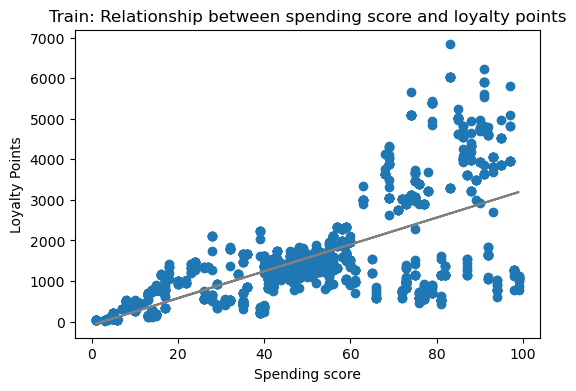

In [16]:
# Plot the graph with a regression line.
plt.figure(figsize=(6,4))
# Visualise the training set.
plt.scatter(x_train, y_train)
plt.plot(x_train, ols.predict(x_train_sm), color='grey')
plt.title("Train: Relationship between spending score and loyalty points")
plt.xlabel("Spending score")
plt.ylabel("Loyalty Points")

plt.show()

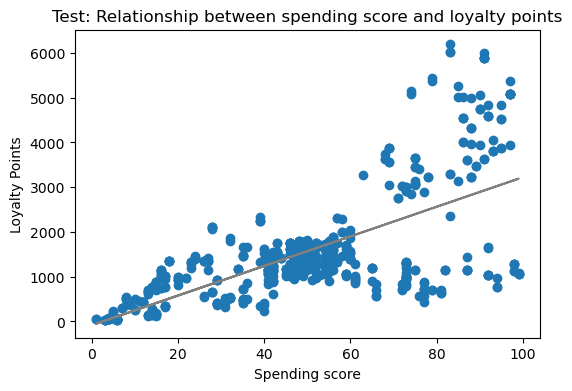

In [17]:
# Visualise the test set.
plt.figure(figsize=(6,4))
plt.scatter(x_test, y_test)
plt.plot(x_test, ols.predict(x_test_sm), color = 'grey')
plt.title("Test: Relationship between spending score and loyalty points")
plt.xlabel("Spending score")
plt.ylabel("Loyalty Points")

plt.show()

#### Insights uncovered:
- **Overall relationship**: As spending score increases, loyalty points generally increase as well. This positive relationship is relatively strong up to a spending score of around 60. Beyond this point, the relationship weakens and becomes more variable.
- **Heteroscedasticity**: The increasing spread of loyalty points at higher spending scores suggests the presence of heteroscedasticity. This indicates that the variance of loyalty points increases with spending score and that additional factors may be influencing behaviour beyond spending alone. This limited the model's predictive accuracy.
- **R-squared**: The R-squared values of 0.448 indicates that approximately 44.8% of the variation in loyalty points is explained by spending score. This represents a meaningful relationship however, a substantial proportion of the variation is not explained in this model suggesting considerable scope for improvement.
- **Standard errors**: The standard error for the spending score (0.982) is small relative to the coefficient itself (33), this gives confidence in that on average loyalty points increase as spending does.

### remuneration vs loyalty 

In [18]:
# Define independent variable.
x2 = reviews_clean[['remuneration']]

# Define dependent variable.
y2 = reviews_clean['loyalty_points'].values.reshape(-1, 1) 

In [19]:
# Create model and print summary of metrics.
# Split the data into training = 0.7 and testing = 0.3 subsets.
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2,
                                                    test_size=0.3,
                                                    random_state=42)

In [20]:
# Add constant
x_train_sm2 = sm.add_constant(x_train2)

# Fit OLS model
ols2 = sm.OLS(y_train2, x_train_sm2).fit()

In [21]:
# Extract the estimated parameters.
parameters = ols2.params

# Standard Errors
standard_errors = ols2.bse

# Predicted values (on test data)
x_test_sm2 =  sm.add_constant(x_test2)
y_pred2 = ols2.predict(x_test_sm2)

In [22]:
# Set the X coefficient and the constant to generate the regression table.
reg_table = pd.DataFrame({
    'Coefficient': parameters,
    'Standard Error': standard_errors
    })

# Rename const to be more readable
reg_table.rename(index={'const':'intercept'}, inplace=True)

# View the output.
reg_table

,Coefficient,Standard Error
intercept,-105.233529,61.163458
remuneration,35.451892,1.155083


In [23]:
print(ols2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     942.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          1.42e-158
Time:                        09:01:53   Log-Likelihood:                -11650.
No. Observations:                1400   AIC:                         2.330e+04
Df Residuals:                    1398   BIC:                         2.332e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -105.2335     61.163     -1.721   

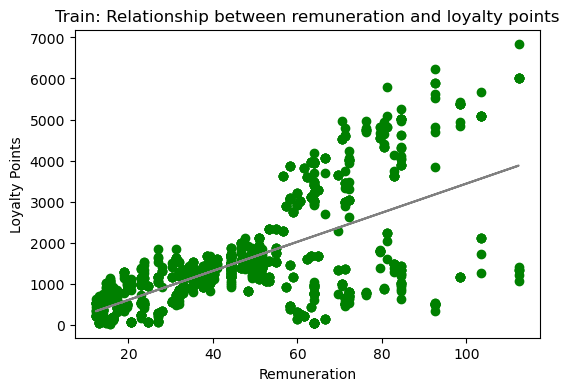

In [24]:
# Plot the graph with a regression line.
plt.figure(figsize=(6,4))
# Visualise the training set.
plt.scatter(x_train2, y_train2, color='green')
plt.plot(x_train2, ols2.predict(x_train_sm2), color='grey')
plt.title("Train: Relationship between remuneration and loyalty points")
plt.xlabel("Remuneration")
plt.ylabel("Loyalty Points")

plt.show()

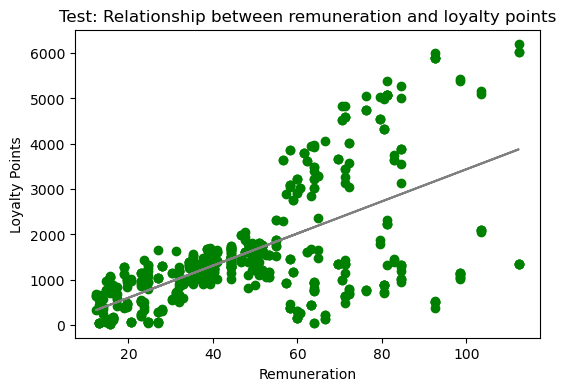

In [25]:
# Visualise the test set.
plt.figure(figsize=(6,4))
plt.scatter(x_test2, y_test2, color='green')
plt.plot(x_test2, ols2.predict(x_test_sm2), color = 'grey')
plt.title("Test: Relationship between remuneration and loyalty points")
plt.xlabel("Remuneration")
plt.ylabel("Loyalty Points")

plt.show()

#### Insights uncovered:
- **Overall relationship**: As remuneration increases, loyalty points generally increase as well. This positive relationship is relatively strong up to a spending score of just below 60. Beyond this point, the relationship weakens and becomes more variable.
- **Heteroscedasticity**: The increasing spread of loyalty points at higher remuneration suggests the presence of heteroscedasticity. This indicates that the variance of loyalty points increases with remuneration and that additional factors may be influencing behaviour beyond remuneration alone. This limited the model's predictive accuracy.
- **R-squared**: The R-squared values of 0.403 indicates that approximately 40.3% of the variation in loyalty points is explained by remuneration. This represents a meaningful relationship however, a substantial proportion of the variation is not explained in this model suggesting considerable scope for improvement.
- **Standard errors**: The standard error for the remuneration (1.15) is small relative to the coefficient itself (35.45), this gives confidence in that on average loyalty points increase as remuneration does.

Remuneration and spending score exhibit similar distributions and spreads, therefore their similar model behaviour and performance are expected.

### age vs loyalty 

In [26]:
# Define independent variable.
x3 = reviews_clean[['age']]

# Define dependent variable.
y3 = reviews_clean['loyalty_points'].values.reshape(-1, 1) 

In [27]:
# Create model and print summary of metrics.
# Split the data into training = 0.7 and testing = 0.3 subsets.
x_train3, x_test3, y_train3, y_test3 = train_test_split(x3, y3,
                                                    test_size=0.3,
                                                    random_state=42)

In [28]:
# Add constant
x_train_sm3 = sm.add_constant(x_train3)

# Fit OLS model
ols3 = sm.OLS(y_train3, x_train_sm3).fit()

In [29]:
# Extract the estimated parameters.
parameters = ols3.params

# Standard Errors
standard_errors = ols3.bse

# Predicted values (on test data)
x_test_sm3 =  sm.add_constant(x_test3)
y_pred3 = ols3.predict(x_test_sm3)

In [30]:
# Set the X coefficient and the constant to generate the regression table.
reg_table = pd.DataFrame({
    'Coefficient': parameters,
    'Standard Error': standard_errors
    })

# Rename const to be more readable
reg_table.rename(index={'const':'intercept'}, inplace=True)

# View the output.
reg_table

,Coefficient,Standard Error
intercept,1730.445181,105.465250
age,-3.675162,2.519742


In [31]:
print(ols3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.127
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.145
Time:                        09:01:54   Log-Likelihood:                -12010.
No. Observations:                1400   AIC:                         2.402e+04
Df Residuals:                    1398   BIC:                         2.403e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1730.4452    105.465     16.408      0.0

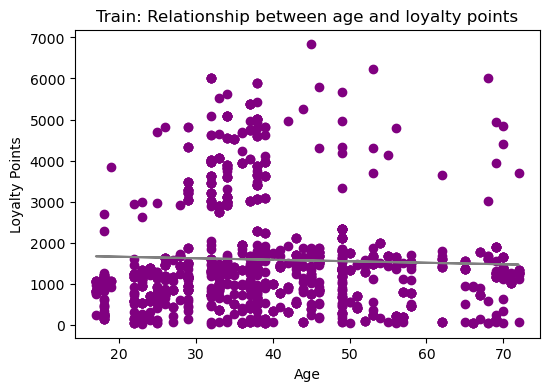

In [32]:
# Plot the graph with a regression line.
plt.figure(figsize=(6,4))
# Visualise the training set.
plt.scatter(x_train3, y_train3, color='purple')
plt.plot(x_train3, ols3.predict(x_train_sm3), color='grey')
plt.title("Train: Relationship between age and loyalty points")
plt.xlabel("Age")
plt.ylabel("Loyalty Points")

plt.show()

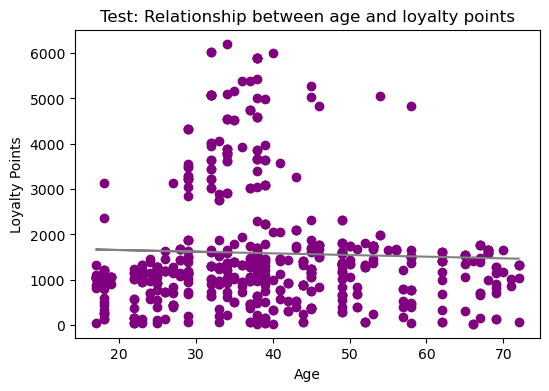

In [33]:
# Visualise the test set.
plt.figure(figsize=(6,4))
plt.scatter(x_test3, y_test3, color='purple')
plt.plot(x_test3, ols3.predict(x_test_sm3), color = 'grey')
plt.title("Test: Relationship between age and loyalty points")
plt.xlabel("Age")
plt.ylabel("Loyalty Points")

plt.show()

#### Insights uncovered:
- **Overall relationship**: There is a veyr weak negative relationship between age and loyalty points. As age increases, loyalty points decreases slightly on average. However, the data is very spread out showing no strong linear pattern. This suggests that age is not a meaningful predictor of loyalty behaviour on its own. 
- **R-squared**: The R-squared values of 0.002 indicates that approximately 0.2% of the variation in loyalty points is explained by age. This demonstrates that age has almost no explanatory power in this model, with the vast majority remains unexplained.
- **Standard errors**: The standard error for the age (2.519) is relatively large compared to the coefficient itself (-3.675), indicating that the estimated effect of age is imprecise and weak. This reinforces the conclusion that age is not a reliable predictor of loyalty points.

## Multiple Linear Regression (MLR)
As a result of the above analysis, no single predictor sufficiently explains loyalty behaviour. I think combining multiple features may improve explanatory and predictive power therefore i will conduct a multiple linear regression below.

In [34]:
# Define the dependent variable.
y = reviews_clean['loyalty_points'] 

# Define the independent variable.
X = reviews_clean[['age', 'spending_score', 'remuneration']] 

In [35]:
# Create train and test data sets.
x_train, x_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

In [36]:
# Training the model using the 'statsmodel' OLS library.
x_train_sm = sm.add_constant(x_train)

# Fit the model with the added constant.
mlr_model = sm.OLS(y_train, x_train_sm).fit()

# Print the summary.
print(mlr_model.summary())  

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     2846.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:01:54   Log-Likelihood:                -12246.
No. Observations:                1600   AIC:                         2.450e+04
Df Residuals:                    1596   BIC:                         2.452e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -2197.0105     58.134    -37.

In [37]:
# Create a regression table
reg_table = pd.DataFrame({
    'Coefficient': mlr_model.params,
    'Standard Error': mlr_model.bse
    })

# Rename const to be more readable
reg_table.rename(index={'const':'intercept'}, inplace=True)

# View regression table
reg_table

,Coefficient,Standard Error
intercept,-2197.010511,58.133738
age,11.013695,0.973586
spending_score,33.968073,0.505076
remuneration,34.245656,0.552312


In [38]:
# Predictions on the test set
x_test_sm = sm.add_constant(x_test)

# Set the predicted response vector.
Y_pred = mlr_model.predict(x_test_sm) 

In [39]:
# Check the model performance metrics
# Checking the value of R-squared, intercept and coefficients.
print("Test R-squared: ", r2_score(y_test,Y_pred))
print("MAE: ", metrics.mean_absolute_error(y_test,Y_pred))
print("MSE: ", metrics.mean_squared_error(y_test,Y_pred))

Test R-squared:  0.8290723396315803
MAE:  402.2350305637691
MSE:  277188.7023322059


In [40]:
# Check multicollinearity.
x_vif = sm.add_constant(x_train)

# Create an empty DataFrame. 
vif = pd.DataFrame()

# Calculate the VIF for each value.
vif['VIF Factor'] = [variance_inflation_factor(x_vif.values,
                                               i) for i in range(x_vif.values.shape[1])]

# Create the feature columns.
vif['features'] = x_vif.columns

# Print the values to one decimal points.
print(vif.round(1))

   VIF Factor        features
0        20.7           const
1         1.1             age
2         1.1  spending_score
3         1.0    remuneration


In [41]:
# Determine heteroscedasticity.
be_test = sms.het_breuschpagan(mlr_model.resid, mlr_model.model.exog) 

# print values
terms = ['LM stat', 'LM Test p-value', 'F-stat', 'F-test p-value']
dict(zip(terms, be_test))

{'LM stat': np.float64(39.20687709402326),
 'LM Test p-value': np.float64(1.569051868116325e-08),
 'F-stat': np.float64(13.36375609804432),
 'F-test p-value': np.float64(1.2899128216958638e-08)}

#### Insights uncovered:
- **R-sqaured**: The MLR linear regression model explains a substantial proportion of the variation in loyalty points, with an R-squared of 0.842 on the training dataset and 0.829 on the test dataset. This represents a significant improvement over single variable models and indicates strong explanatory power even with unseen data.
- **Standard Error**: All three features have small standard errord relative to their coefficients, indicating that their effects are estimated with high precision. Interesting to note that age displays a positive and statistically significant relationship with loyalty once spending and remuneration are accounted for.
- **Predictive accuracy**: The model shows a mean absolute error (MAE) of 402. Relative to the distribution of loyalty this is acceptable, suggesting this model captures loyalty behaviour quite accurately.
- **Multi-collinearity**: The Variance Inflation Factor (CIF) values for all predictors are close to 1, indicating no evidence of multicollinearity. This confirms that the predictors provide independent information and that coefficient estimates are reliable.
- **Heteroscedasticity**: The outcome of the breuschpagan test suggests heteroscedasticity is present. Therefore, while the model explains a large proportion of the variation in loyalty points, the prediction accuracy is not consistent across all customers. A potential improvement to this model could be to apply a log-transformation to loyalty_points to reduce the impact of extreme values.

## Decision Trees effectiveness to understand feature contribution to loyalty accumulation

In [42]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt

In [43]:
# View your dataframe
reviews_clean.head(2)

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.3,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.3,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...


In [44]:
# Create dummy variables for 'gender' column
gender_dummies = pd.get_dummies(reviews_clean['gender'], prefix='gender', drop_first = True)
reviews_clean = pd.concat([reviews_clean, gender_dummies.astype(int)], axis=1)

# Create dummy variables for 'education' column
education_dummies = pd.get_dummies(reviews_clean['education'], prefix='education', drop_first = True)

# Join the new columns to the DataFrame.
reviews_clean = pd.concat([reviews_clean, education_dummies.astype(int)], axis=1)

# Drop the original string columns
reviews_clean.drop(['gender', 'education'], axis=1, inplace=True)

# View the updated DataFrame
reviews_clean.head()

,age,remuneration,spending_score,loyalty_points,product,review,summary,gender_Male,education_PhD,education_diploma,education_graduate,education_postgraduate
0,18,12.30,39,210,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,1,0,0,1,0
1,23,12.30,81,524,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,1,0,0,1,0
2,22,13.12,6,40,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless",0,0,0,1,0
3,25,13.12,77,562,263,Amazing buy! Bought it as a gift for our new d...,Five Stars,0,0,0,1,0
4,33,13.94,40,366,291,As my review of GF9's previous screens these w...,Money trap,0,0,0,1,0


In [45]:
# Specify Y.
y = reviews_clean['loyalty_points']

# Specify X.
X = reviews_clean.drop(['loyalty_points','review','summary'], axis = 1)

# Create a VIF dataframe.
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
  
# Calculate VIF for each feature.
# N.b. this is for exploratory analysis only to understand relationships between input features
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

# View the DataFrame.
vif_data.sort_values('VIF',ascending=True)

,feature,VIF
4,gender_Male,1.787337
6,education_diploma,2.365768
3,product,3.149646
8,education_postgraduate,3.592142
5,education_PhD,3.990856
2,spending_score,4.405869
1,remuneration,5.562915
7,education_graduate,6.512057
0,age,8.423223


In [46]:
# Specify that the column loyalty_points 
# should be moved into a separate DataFrame.
cols = reviews_clean.columns[reviews_clean.columns != 'loyalty_points']  

# Split the data training and testing 30/70.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

# Create the 'DecisionTreeRegressor' class 
# (which has many parameters; input only #random_state=0).
regressor = DecisionTreeRegressor(random_state=42)

# Fit the regressor object to the data set.
regressor.fit(X_train,y_train)  

DecisionTreeRegressor(random_state=42)

In [47]:
# Predict the response for the data test.
y_predict = regressor.predict(X_test)  

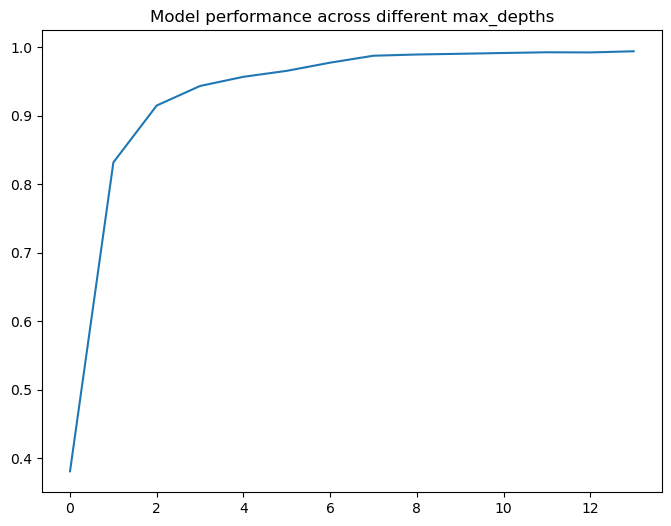

In [48]:
# List of values to try for max_depth:
max_depth_range = list(range(1, 15))
# List to store the accuracy for each value of max_depth:
accuracy = []
for depth in max_depth_range:
    
    dtrp = DecisionTreeRegressor(max_depth = depth, random_state = 42)
    dtrp.fit(X_train, y_train)
    score = dtrp.score(X_test, y_test)
    accuracy.append(score)



# Plot accuracy values across the range of depth values evaluated
accuracy = pd.DataFrame(accuracy)
fig, ax = plt.subplots(figsize=(8,6))
accuracy.plot(ax=ax,legend=False)
plt.title('Model performance across different max_depths')
plt.show()

In [49]:
# Prune the model.
dtrp = DecisionTreeRegressor(criterion='squared_error',
                             max_depth=6,
                             random_state=42)

# Train the decision tree classifier.
dtrp.fit(X_train,y_train) 
y_predict_p = dtrp.predict(X_test)  

In [50]:
# Check for overfitting with R-squared
print("Training R-squared: ",regressor.score(X_train,y_train))
print("Test R-squared: ",regressor.score(X_test,y_test))
print("Pruned Test R-squared: ",dtrp.score(X_test,y_test))

Training R-squared:  1.0
Test R-squared:  0.9937044218103145
Pruned Test R-squared:  0.9654231585075966


In [51]:
# Evaluate the accuracy of the unpruned model
print("Unpruned MAE: ", metrics.mean_absolute_error(y_test, y_predict))
print("Unpruned MSE: ", metrics.mean_squared_error(y_test, y_predict))
print("Unpruned RMSE: ", math.sqrt(metrics.mean_squared_error(y_test, y_predict)))  

Unpruned MAE:  39.248333333333335
Unpruned MSE:  10197.558333333332
Unpruned RMSE:  100.98296060887368


In [52]:
# Evaluate the accuracy of the unpruned model
print("Pruned MAE: ", metrics.mean_absolute_error(y_test, y_predict_p))
print("Pruned MSE: ", metrics.mean_squared_error(y_test, y_predict_p))
print("Pruned RMSE: ", math.sqrt(metrics.mean_squared_error(y_test, y_predict_p)))  

Pruned MAE:  152.5687808526625
Pruned MSE:  56007.462297727376
Pruned RMSE:  236.65895778044697


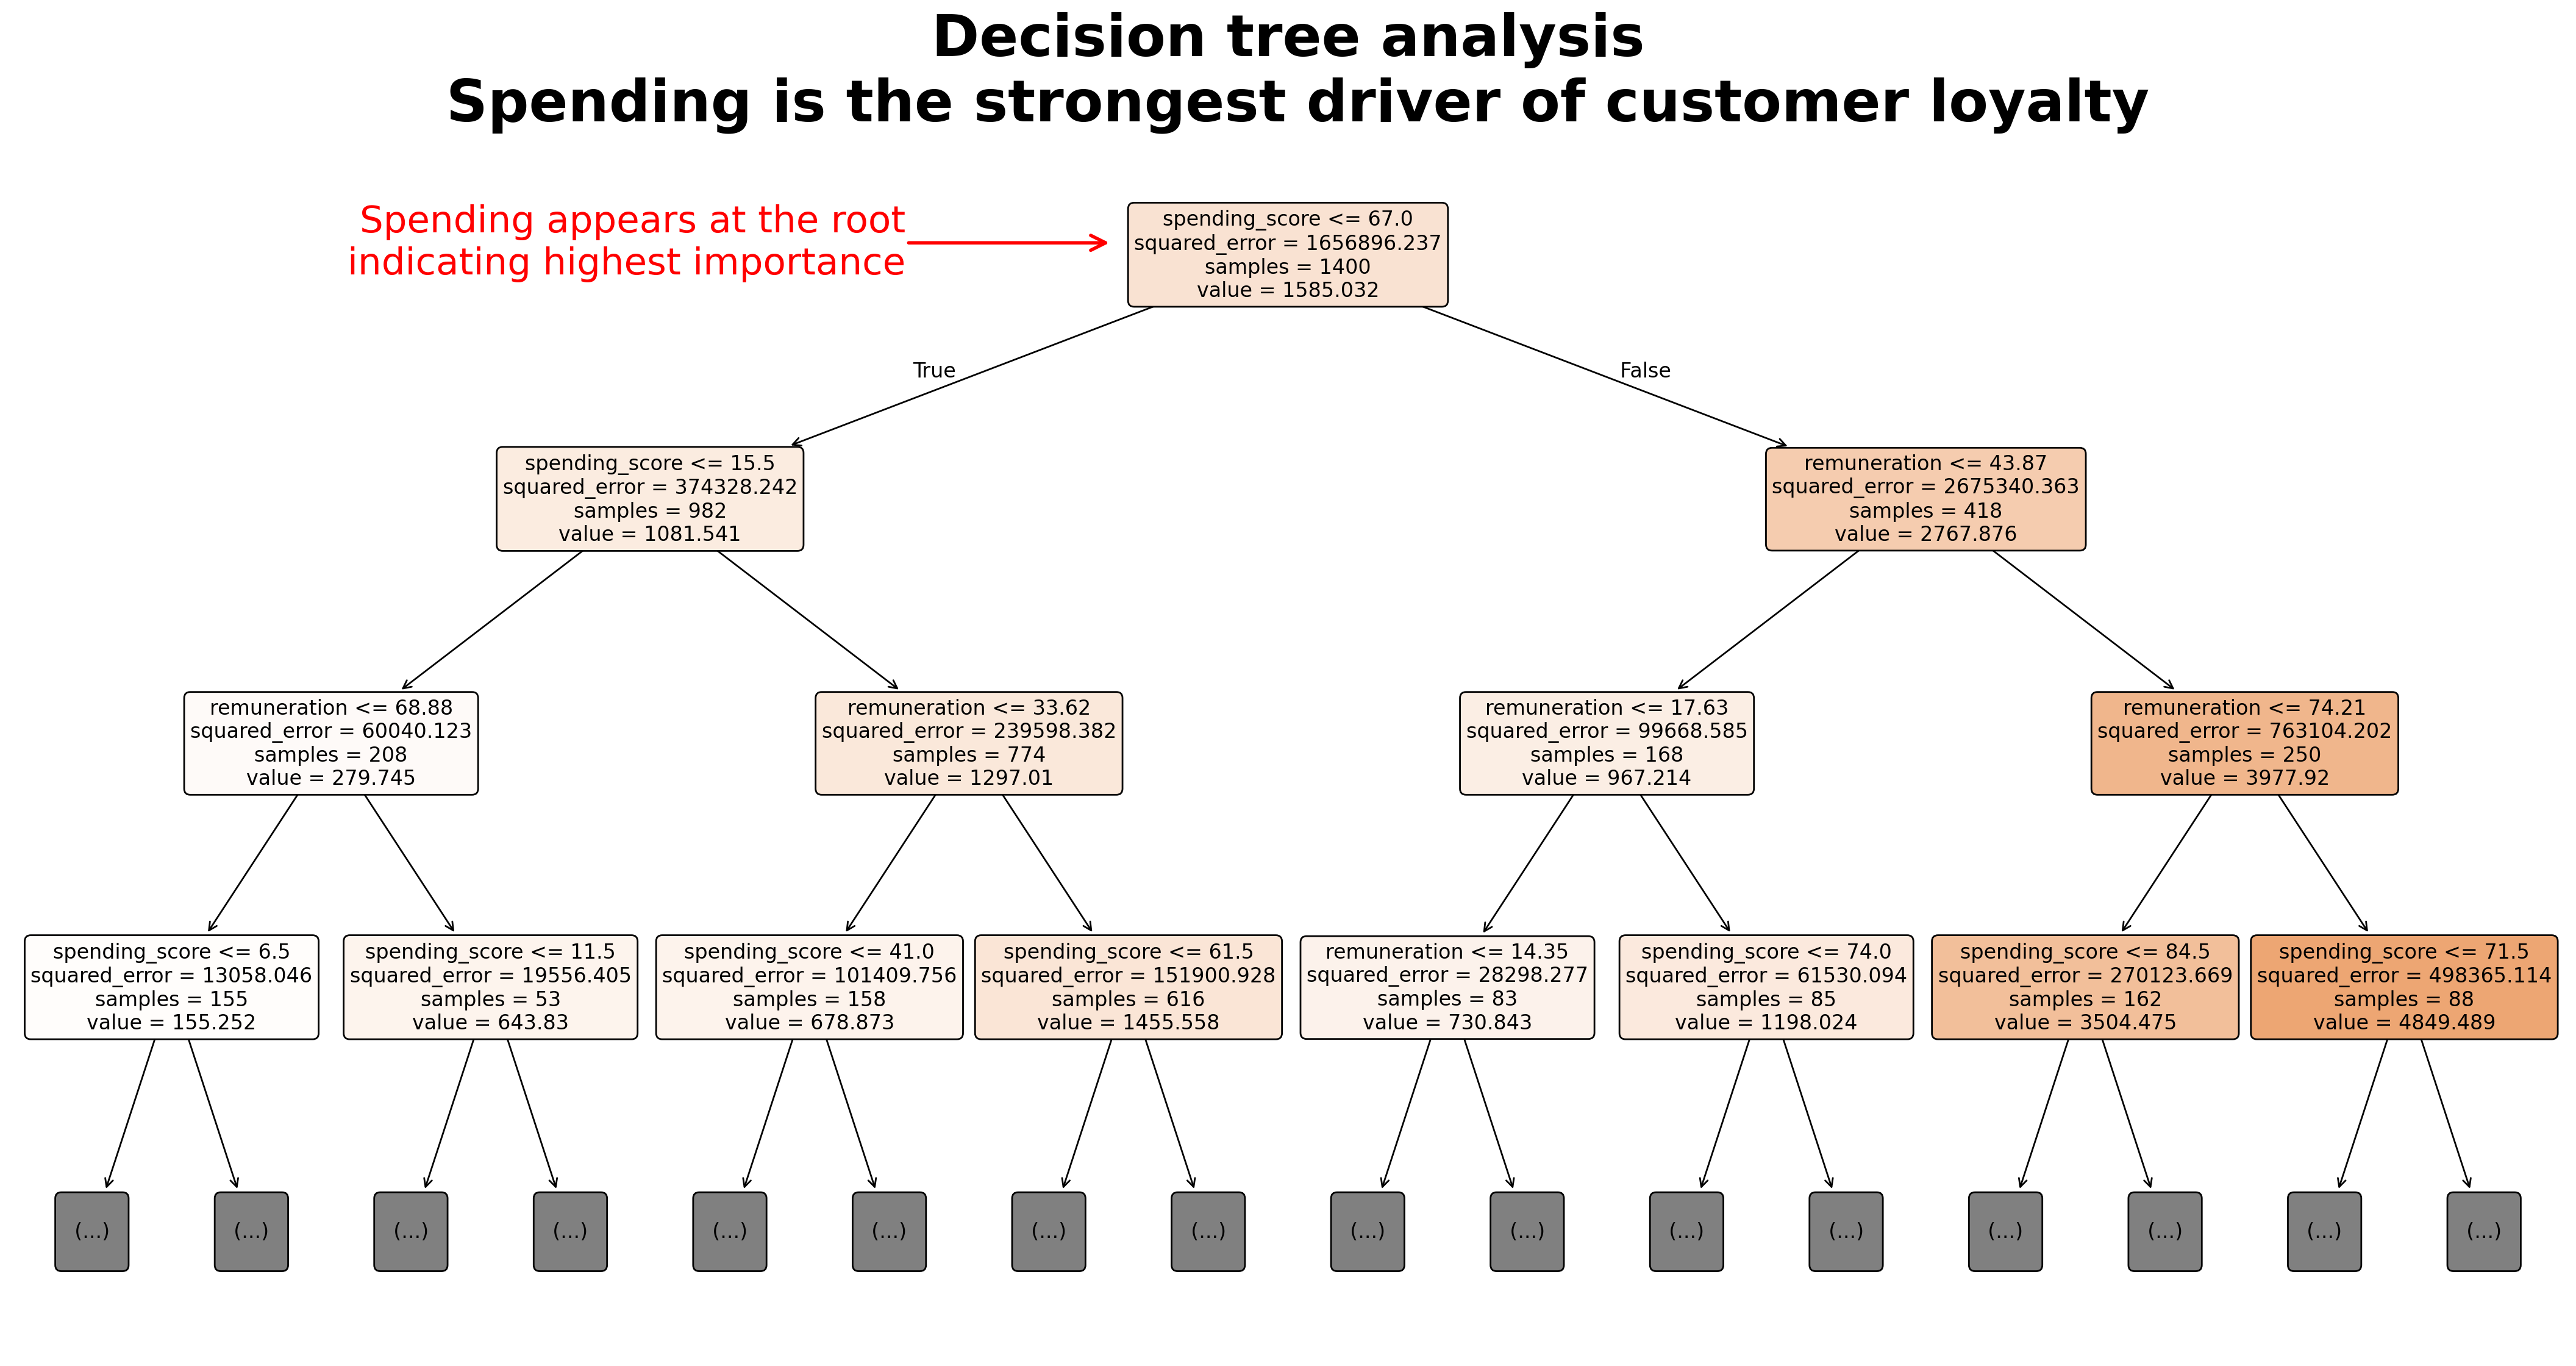

In [53]:
# Predict the response for the test data set.
y_pred = dtrp.predict(X_test)  

# Fit and plot final model.
fig, ax = plt.subplots(figsize=(27, 13),dpi=200)
tree.plot_tree(dtrp, max_depth = 3, filled=True, feature_names=X.columns, rounded=True, fontsize=12)

# Print the plot with plt.show().
plt.title('Decision tree analysis\n Spending is the strongest driver of customer loyalty', fontsize=34, fontweight='bold')

# Add an arrow pointing to the root
plt.annotate(
    'Spending appears at the root\nindicating highest importance',
    xy=(0.43,0.91),
    xytext=(0.35,0.91),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='->',
        linewidth=2,
        color='red',
        shrinkA=0,
        shrinkB=0
    ),
    ha='right',
    va='center',
    fontsize=22,
    color='red'
)
plt.show()  

#### Insights to note:
- **VIF**: No feature has a VIF above 10, indicating limited to no correlation between variables. This suggests there is not a multicollinearity problem. Some conservative thresholds suggest VIF above 5 could show moderate correlation, which would impact age, education and remuneration, but not problematically so.
- **R-squared**: the unpruned decision tree achieves an R-squared of 1.0 on the training data. The model also maintains a very high R-squared on the test dataset (0.9937), demonstrating it generalises well and is not overfitted. After pruning, the R-squared reduces slightly but is still very high (0.965). Therefore, the pruned model has better readability and is less complex, while still showing strong predictive performance. 
- **Predictive metrics**: the unpruned model has a very low MAE of 39.248. The pruned model has a higher MAE at 152.569. However, given that loyalty spans several thousands, these are still relatively small indicating both models predict loyalty accurately. 
- **Pruning depth**: The validation curve shows that performance improves rapidly up to a max_depth of 5-6, after which the gains plateau. Therefore, selecting a maximum depth of 6 provides a strong balance between the models performance and its readability. 
- **Feature importance**: The decision tree reveals that spending score is the most influential feature affecting loyalty, being at the root of the tree. Remuneration follows as a secondary factor, while age does not appear in the top few splits suggesting a weaker influence on loyalty.

## Clustering with k-means to better understand customer behaviour

In [54]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

In [55]:
# Create a new DataFrame containing the remuneration and spending_score columns
df3 = reviews_clean[['remuneration','spending_score']].copy()

# View DataFrame.
df3.head()

,remuneration,spending_score
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40


In [56]:
# Explore the data.
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   remuneration    2000 non-null   float64
 1   spending_score  2000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


In [57]:
# Descriptive statistics.
df3.describe()

,remuneration,spending_score
count,2000.000000,2000.000000
mean,48.079060,50.000000
std,23.123984,26.094702
min,12.300000,1.000000
25%,30.340000,32.000000
50%,47.150000,50.000000
75%,63.960000,73.000000
max,112.340000,99.000000


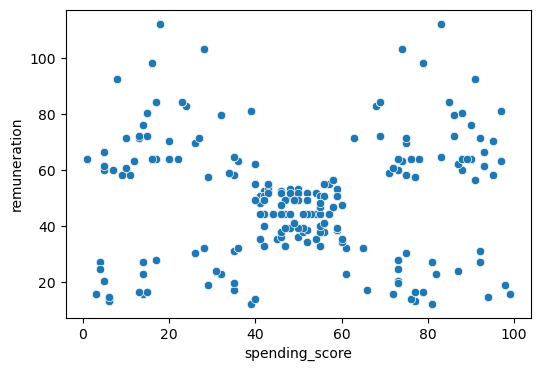

In [58]:
# Create a scatterplot with Seaborn.
plt.figure(figsize=(6,4))
sns.scatterplot(x='spending_score',
                y='remuneration',
                data=df3)

# View output
plt.show()

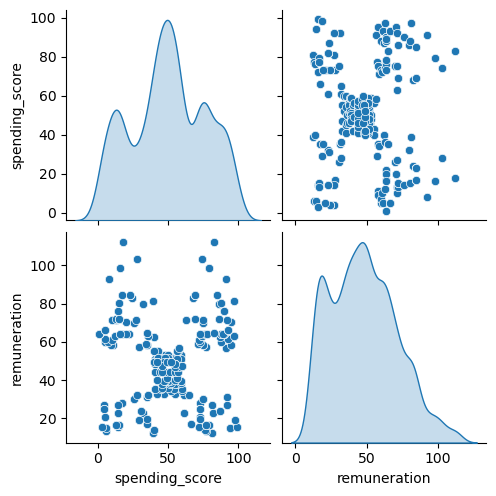

In [59]:
# Create a pairplot with remuneration.
x = df3[['spending_score', 'remuneration']]

sns.pairplot(df3,
             vars=x,
             diag_kind='kde')

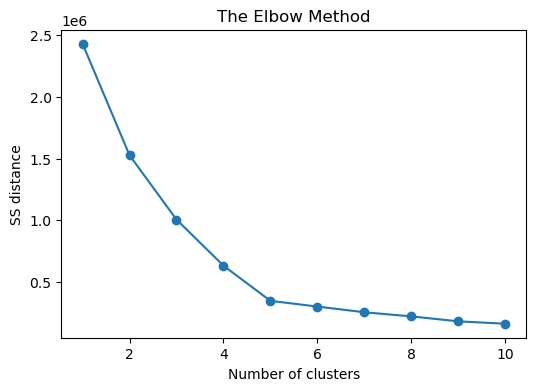

In [60]:
# Determine the number of clusters: Elbow method.
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=300,
                    n_init=10,
                    random_state=0)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot the elbow method.
plt.figure(figsize=(6,4))
plt.plot(range(1, 11),
         ss,
         marker='o')

# Insert labels and title.
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SS distance")

plt.show()

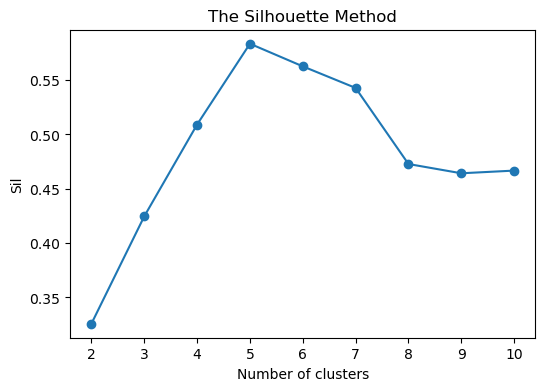

In [61]:
# Determine the number of clusters: Silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k).fit(x)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(x,
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.figure(figsize=(6,4))
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette Method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")

plt.show()

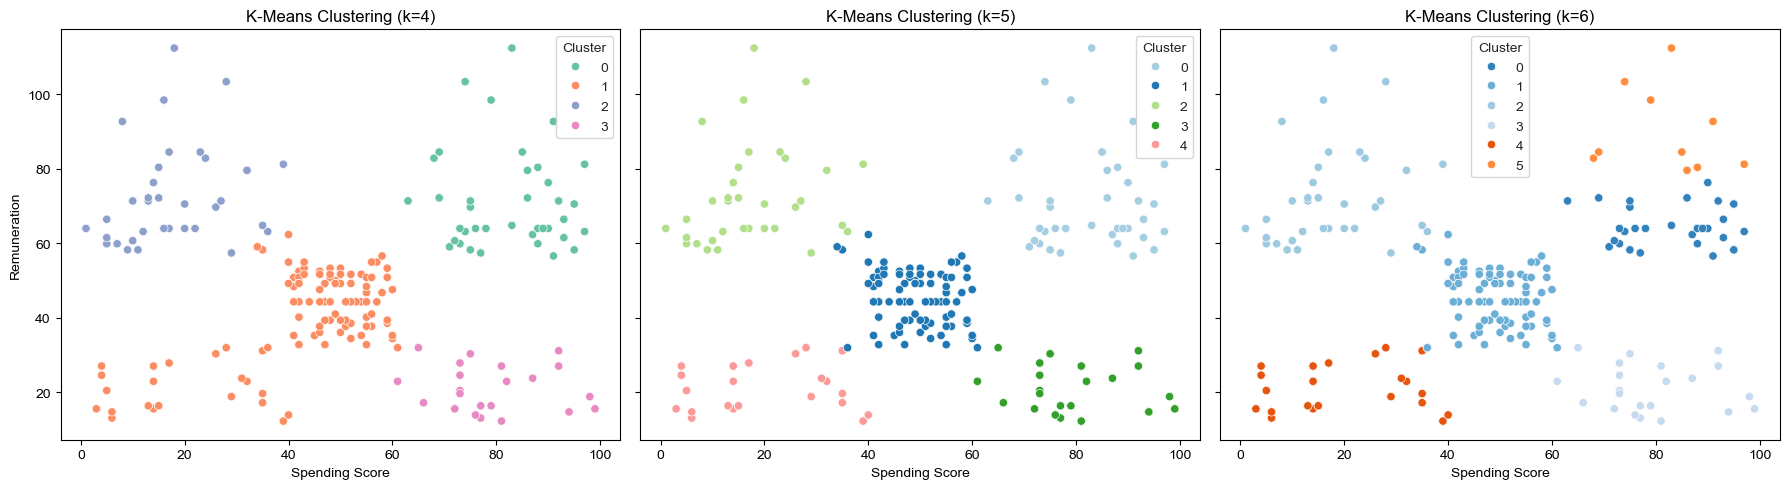

In [62]:
# Loop through different values of k to evaluate their effectiveness
# Define the values of k to evaluate
k_values = [4,5,6]

# Create a 3 plots in one row figure layout
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharex=True, sharey=True)
sns.set_style('whitegrid')

# Define a different color palette per plot
palettes = ['Set2', 'Paired', 'tab20c']

for ax, k, palette in zip(axes, k_values, palettes):
    kmeans = KMeans(n_clusters = k, 
                max_iter = 15000,
                init='k-means++',
                random_state=42
                   )
    clusters = kmeans.fit_predict(df3)

    # Create a copy for plotting
    plot_df = df3.copy()
    plot_df['Cluster'] = clusters

    # Plot clusters
    sns.scatterplot(
        data=plot_df,
        x='spending_score',
        y='remuneration',
        hue='Cluster',
        palette=palette,
        ax=ax,
        legend='full'
    )

    ax.set_title(f'K-Means Clustering (k={k})')
    ax.set_xlabel('Spending Score')
    ax.set_ylabel('Remuneration')

plt.tight_layout()
plt.show()

#### Choosing the most appropriate k:
- **k=4**: the clusters are too broad, particularly towards the bottom left we see that cluster 1 covers a large radius of data points.
- **k=5**: there are 5 visually distinct clusters, each with a clear pattern.
- **k=6**: clusters 0 and 5 are much smaller, with less obvious pattern for separation, potentially seeing over-clustering.
- **Elbow**: clustering error decreases significantly up to k=5, after this adding more clusters stops giving meaningful improvement.
- **Silhouette**: the validation score increasing significantly up to k=5, then begins to consistently drop for each k after, suggesting that 5 clusters fits the data into each cluster compared to neighbouring clusters the best.

Due to the above analysis, i will proceed with 5 clusters, as the most optimal.

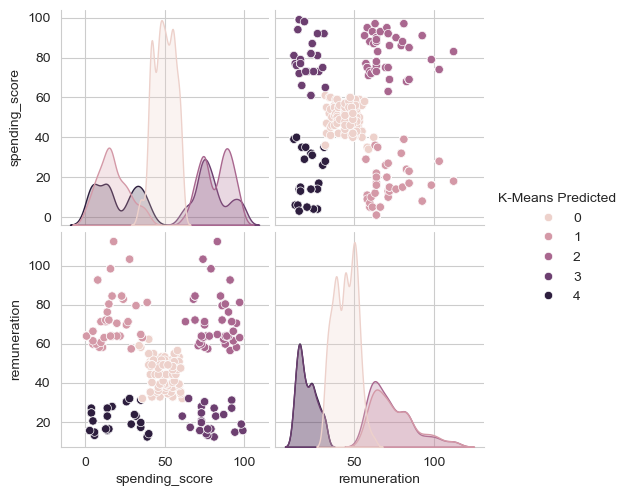

In [63]:
# Apply the final model
kmeans = KMeans(n_clusters = 5, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

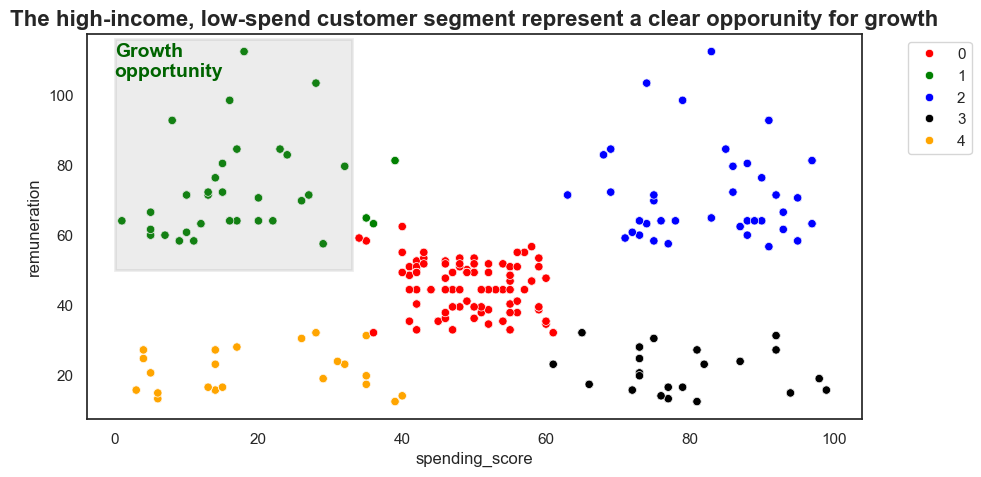

K-Means Predicted
0    774
2    356
1    330
4    271
3    269
Name: count, dtype: int64

In [64]:
# Visualising the clusters.
# Set plot size.
sns.set(rc = {'figure.figsize':(10, 5)})
sns.set_style('white')
# Create a scatterplot.
sns.scatterplot(x='spending_score' , 
                y ='remuneration',
                data=x,
                hue='K-Means Predicted',
                palette=['red', 'green', 'blue', 'black','orange'])

# Formatting
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('The high-income, low-spend customer segment represent a clear opporunity for growth',
         fontsize = 16,
         fontweight='bold')

# Add a rectangle to highlight opportunity segment
from matplotlib.patches import Rectangle
plt.gca().add_patch(
    Rectangle(
        (0,50),
        33,
        66,
        linewidth=2,
        edgecolor='grey',
        facecolor='grey',
        alpha=0.15
    )
)

plt.text(
    0,115,
    'Growth\nopportunity',
    fontsize=14,
    fontweight='bold',
    color='darkgreen',
    ha='left',
    va='top'
)

plt.show()

# View the DataFrame.
x['K-Means Predicted'].value_counts()

In [65]:
# Visualising the clusters.
print(x.head())

   spending_score  remuneration  K-Means Predicted
0              39         12.30                  4
1              81         12.30                  3
2               6         13.12                  4
3              77         13.12                  3
4              40         13.94                  4


#### Cluster analysis:
- **Cluster 0**: This is the largest group at 774 customers. This represent the core base reflecting the typical Turtle Games customer. This group should be the primary target, with marketing initiatives prioritising broach campaigns to see small improvements in engagement, potentially increasing this groups spending. 
- **Cluster 1**: this cluster is the third largest, showing lower spending with high remuneration, these are potentially customers with under-utilised engagement and an untapped opportunity. This group has the potential for high-growth, creating more targeted and personalised campaigns to boost spending and loyalty could convert them to more high-value customers. 
- **Cluster 2**: this is the second largest cluster with high spend and high remuneration. These customers have the spending power and could potentially be targeted with more premium offerings.
- **Cluster 3**: these are customers with high spending and low remuneration. This relfects our most engaged and enthusiastic customers despite lower income. Ensuring these customers should be targeted with initiatives to help maintain engagement.
- **Cluster 4**: this cluster reflects customers with low spending and low remuneration and should be a low priority target audience.

## Using NLP and text analytics to determine sentiment from reviews

In [66]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

!pip install wordcloud
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

In [67]:
# Create a new DataFrame containing the review and summary columns
df4 = reviews_clean[['review','summary']].copy()

# View DataFrame.
df4.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [68]:
# Explore data set.
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   review   2000 non-null   object
 1   summary  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [69]:
# Determine if there are any missing values.
df4.isnull().sum()

review     0
summary    0
dtype: int64

In [70]:
# Wrangle both review and summary to covert to lowercase, join with a space, and remove punctuation
text_columns = ['review', 'summary']

for col in text_columns:

    # Convert to lowercase and join with a space
    df4[col] = df4[col].apply(
        lambda x: " ".join(x.lower() for x in x.split())
    )

    # Remove puntuation
    df4[col] = df4[col].str.replace('[^\w\s]','',regex=True)

    # Preview result
    print(f'\nPreview cleaned {col}:')
    display(df4[col].head())


Preview cleaned review:


0    when it comes to a dms screen the space on the...
1    an open letter to galeforce9 your unpainted mi...
2    nice art nice printing why two panels are fill...
3    amazing buy bought it as a gift for our new dm...
4    as my review of gf9s previous screens these we...
Name: review, dtype: object


Preview cleaned summary:


0    the fact that 50 of this space is wasted on ar...
1    another worthless dungeon masters screen from ...
2                       pretty but also pretty useless
3                                           five stars
4                                           money trap
Name: summary, dtype: object

In [71]:
# Check the number of duplicate values
for col in text_columns:
    print(f'Duplicate {col} values:', df4[col].duplicated().sum())

print('Duplicated review-summary pairs:',
     df4.duplicated(subset=text_columns).sum())

Duplicate review values: 50
Duplicate summary values: 649
Duplicated review-summary pairs: 39


In [72]:
# Drop duplicates in both columns.
df4.drop_duplicates(subset=['review','summary'], inplace=True)

# Preview data.
df4.reset_index(inplace=True)
df4.head()

,index,review,summary
0,0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,3,amazing buy bought it as a gift for our new dm...,five stars
4,4,as my review of gf9s previous screens these we...,money trap


In [73]:
# Create new DataFrame (copy DataFrame).
text = pd.DataFrame(df4)

# View DataFrame.
text.head()

,index,review,summary
0,0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,3,amazing buy bought it as a gift for our new dm...,five stars
4,4,as my review of gf9s previous screens these we...,money trap


In [74]:
# Apply tokenisation to both review and summary
for col in text_columns:
    text[col] = text[col].apply(word_tokenize)

# Check result
text.head()

,index,review,summary
0,0,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was..."
1,1,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,..."
2,2,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,3,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,4,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]"


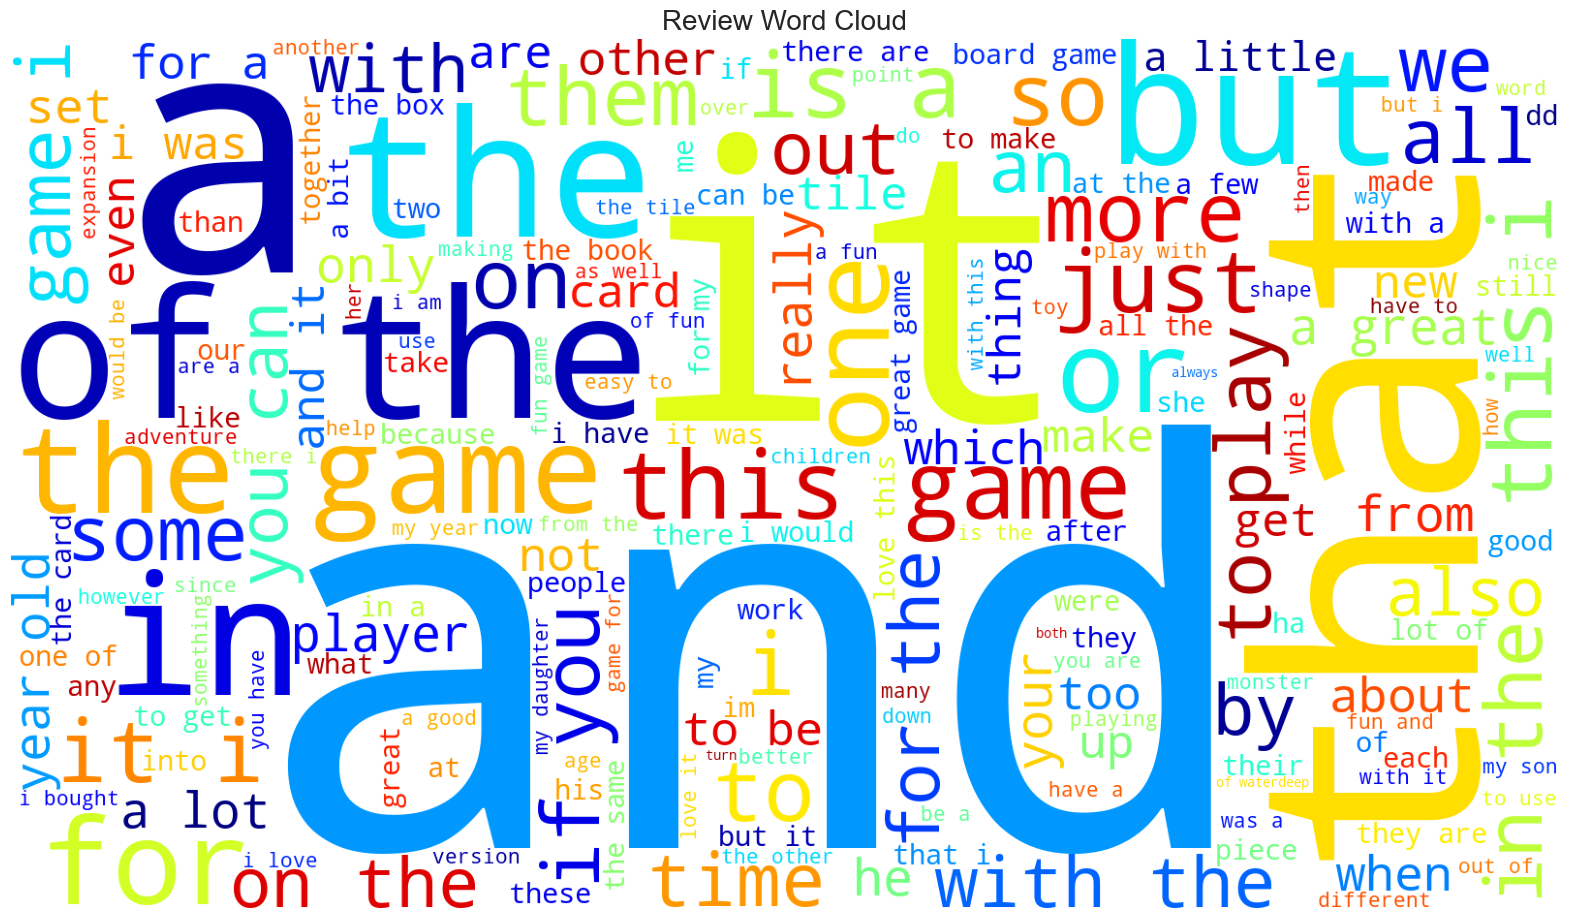

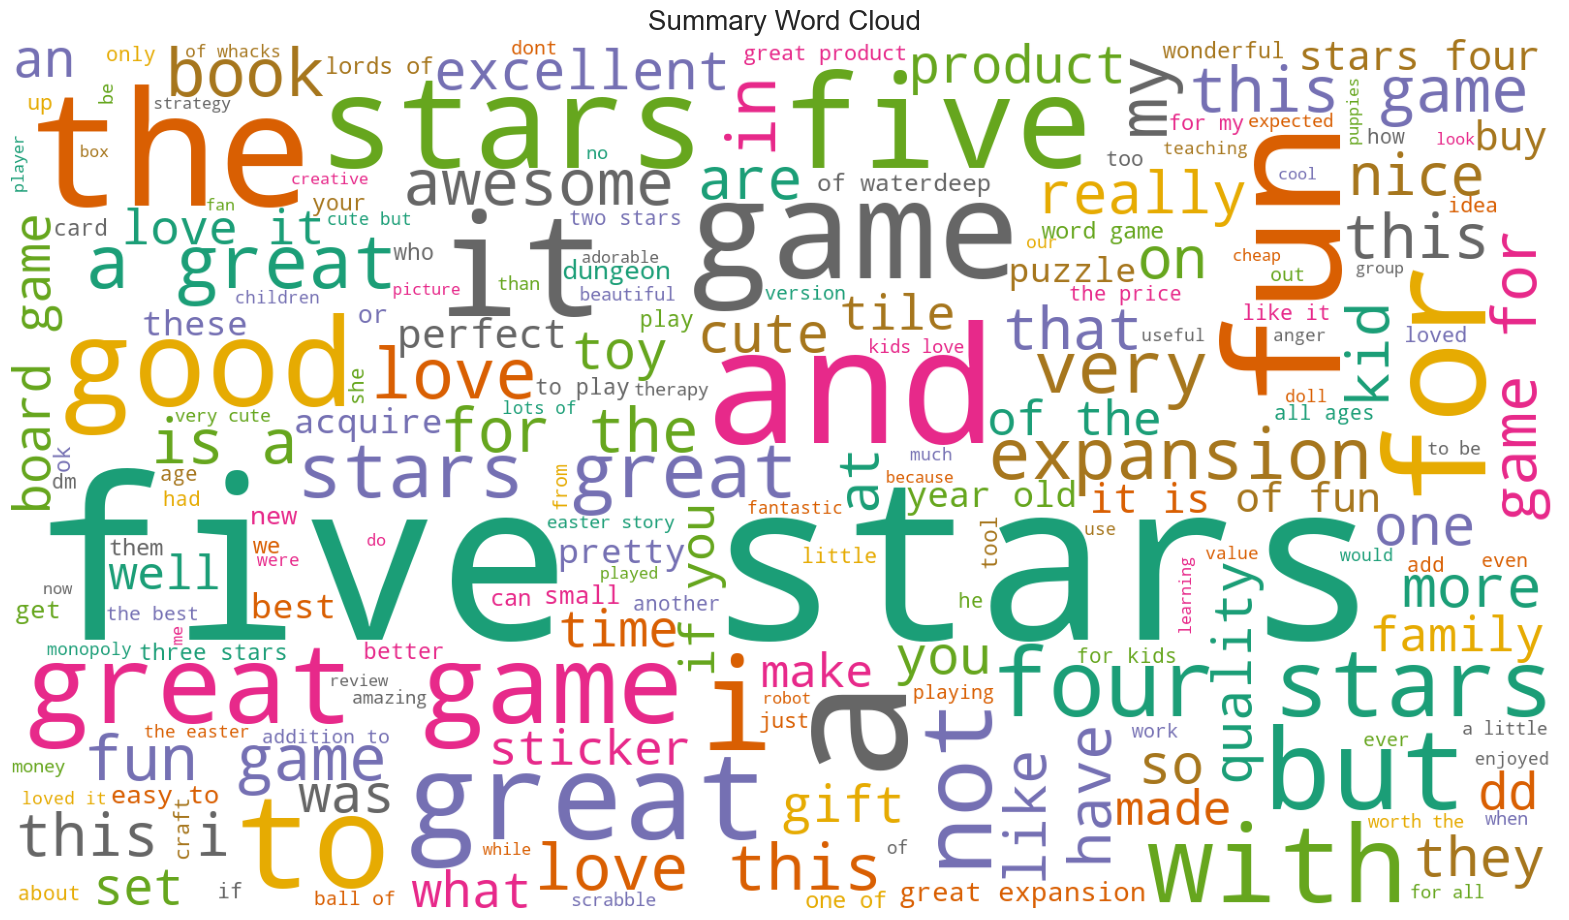

In [75]:
# String all the comments together in a single variable and create a word cloud
# Configuration
wordcloud_configs = [
    {
        'label':'Review',
        'column':'review',
        'colormap':'jet'
    },
    {
        'label':'Summary',
        'column':'summary',
        'colormap':'Dark2' 
    }
]

sns.set(color_codes=True)

for cfg in wordcloud_configs:

    # Join tokenised text into one string
    all_text = ' '.join(text[cfg['column']].apply(' '.join))

    # Create word cloud
    wc = WordCloud(width = 1600, height = 900, 
                background_color ='white',
                colormap = cfg['colormap'], 
                stopwords = 'none',
                min_font_size = 10).generate(all_text)

    # Plot word cloud
    plt.figure(figsize = (16, 9), facecolor = None) 
    plt.imshow(wc) 
    plt.axis('off') 
    plt.title(f'{cfg['label']} Word Cloud', fontsize=20)
    plt.tight_layout(pad = 0) 
    plt.show()

### Comments on appropriate use of this visualisation
This type of visualisation is highly intuitive for non-technical stakeholders, as larger words can be easily interpreted as being more prominent due to their higher frequency within the data. As a result, word clouds can provide a quick indication of what topics or themes are most commonly discussed. However, on their own they do not lead to valuable or actionable insights and show not be used in isolation for decision-making. Instead, they are best suited as brainstorming or exploratory tool, helping analysts identify potential areas for further investigation that may later support meaningful insights.

Looking specifically at the word clouds above, additional data pre-processing would improve their usefulness. In particular, common stopwords such as 'and', 'the', and 'to' currently appeare prominently despite carrying little to no sentiment or analytical value. Removing these terms would allow more meaningful words to surface and improve the interpretability of the visualisation. 

In [76]:
# Determine the frequency distribution in both review and summary
all_tokens = {}

for col in ['review', 'summary']:

    # Flatten list of token lists into a single list
    all_tokens[col] = [token for tokens in text[col] for token in tokens]

    # Frequency distribution
    freq_dist = FreqDist(all_tokens[col])

    print(f'\nFrequency distribution for {col}')
    display(freq_dist)


Frequency distribution for review


FreqDist({'the': 5451, 'and': 3233, 'to': 3162, 'a': 3160, 'of': 2488, 'i': 2090, 'it': 2083, 'is': 1782, 'this': 1776, 'game': 1671, ...})


Frequency distribution for summary


FreqDist({'stars': 427, 'five': 342, 'game': 319, 'great': 295, 'the': 261, 'a': 240, 'for': 232, 'fun': 218, 'to': 192, 'and': 168, ...})

In [77]:
# Wrangle both review and summary to delete alpanum and remove stopwords
# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

# put the token lists into a dictionary
token_sets = {
    'review': all_tokens['review'],
    'summary': all_tokens['summary']
}

cleaned_tokens = {}
cleaned_string = {}

# Loop over both review and summary
for label, tokens in token_sets.items():

    # Keetp only alphanumeric tokens
    tokens_alnum = [word for word in tokens if word.isalnum()]

    # Remove stopwords
    tokens_clean = [word for word in tokens_alnum if word.lower() not in english_stopwords]

    # Store cleaned tokens
    cleaned_tokens[label] = tokens_clean

    # Join tokens back into a string
    cleaned_string[label] = ' '.join(tokens_clean)

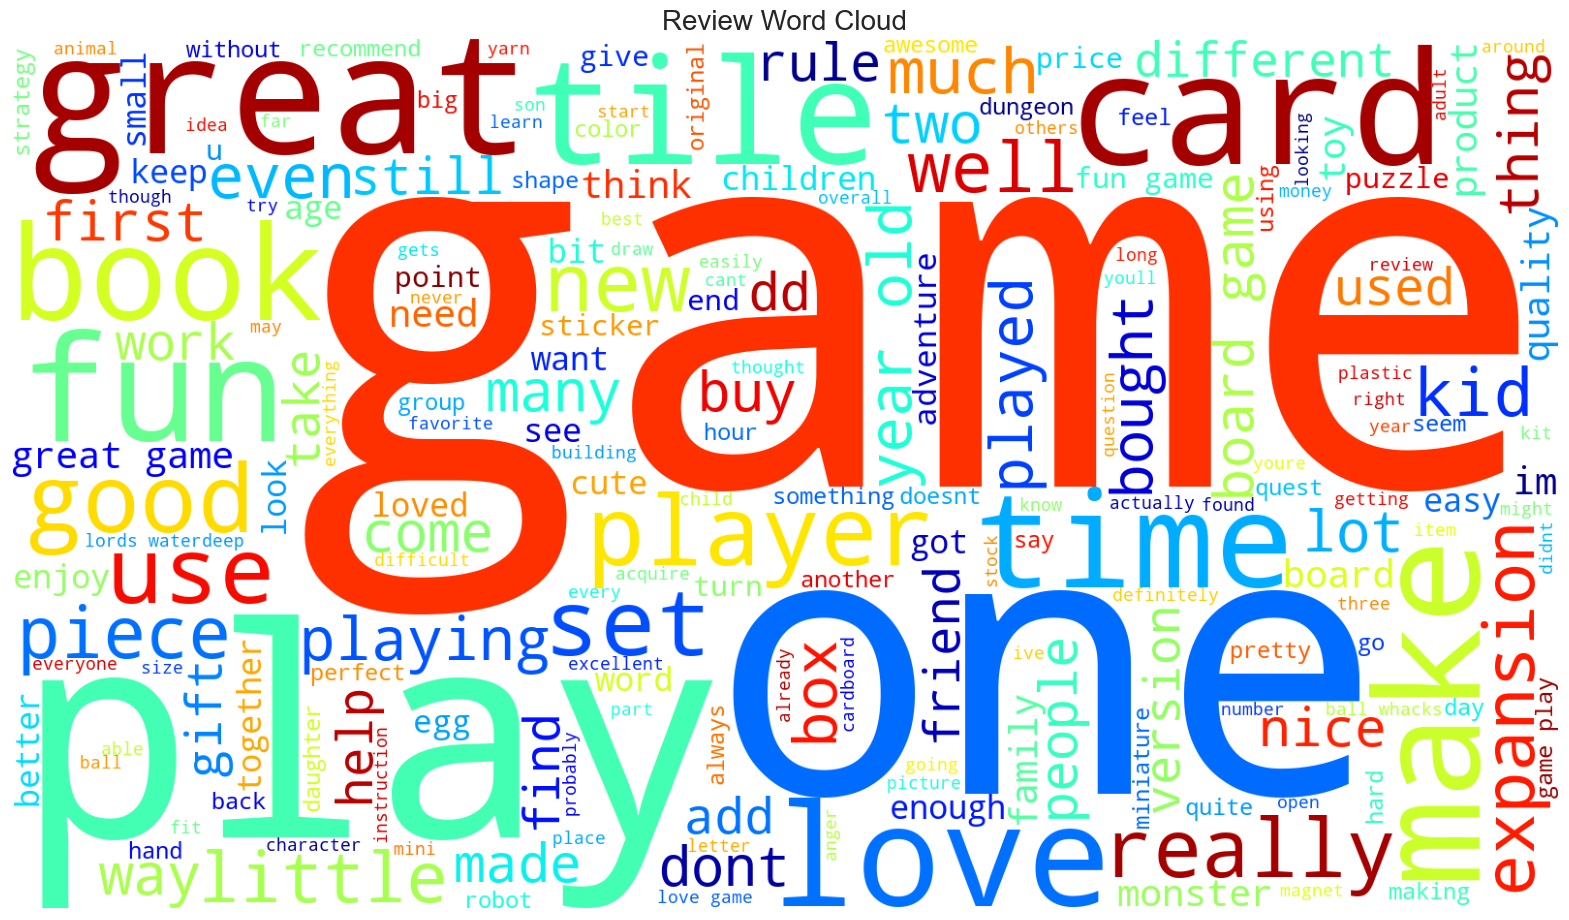

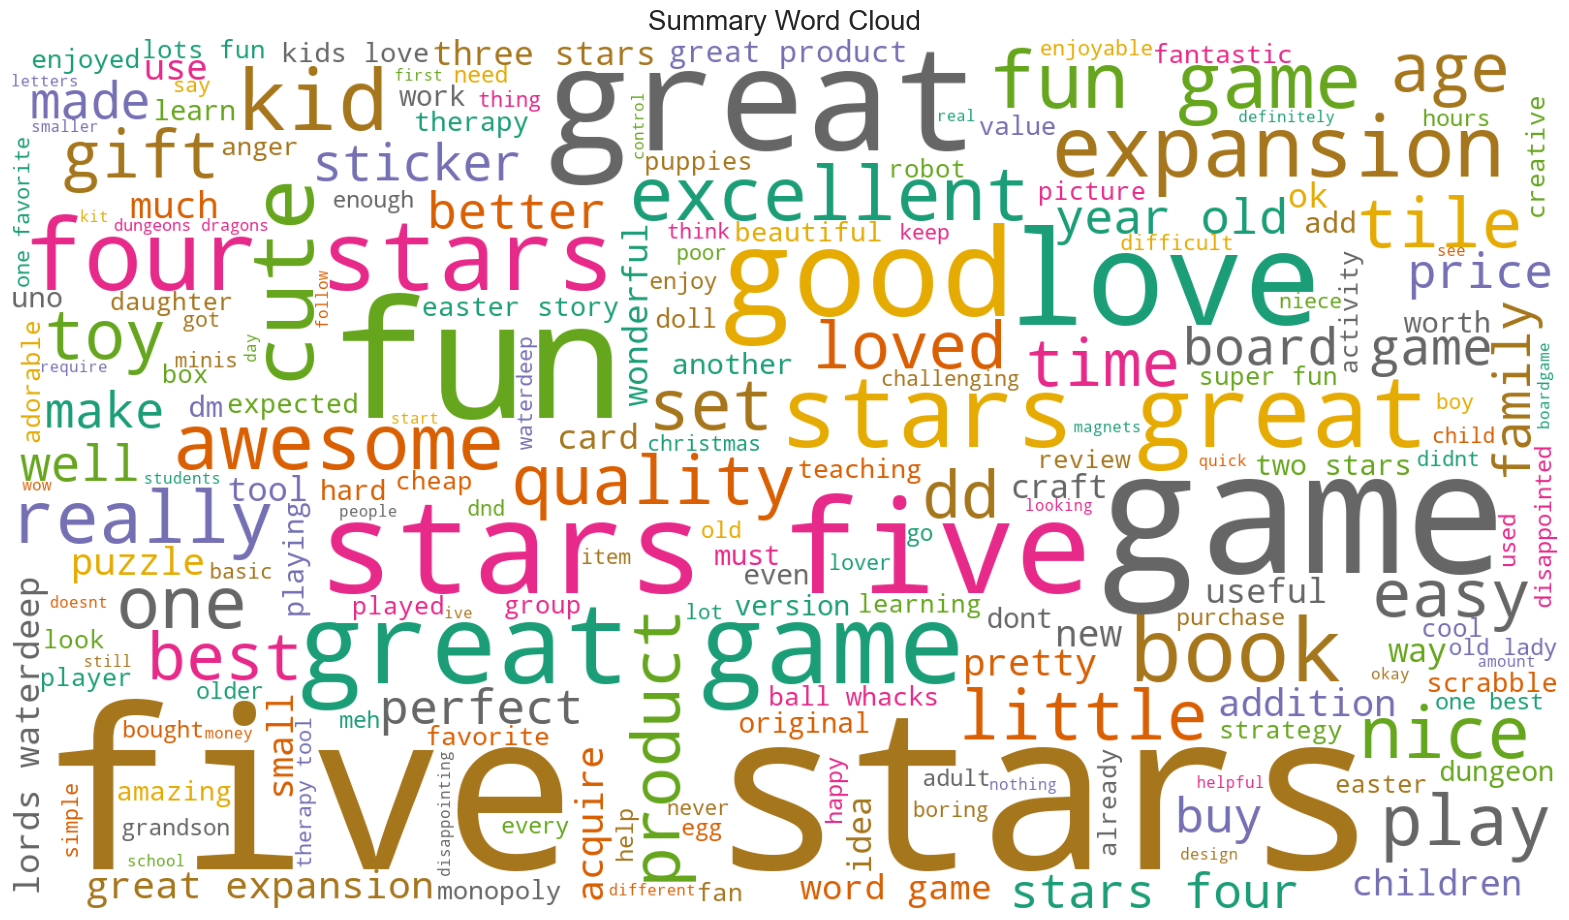

In [78]:
# Re-create word clouds without stopwords
# Configuration
wordcloud_configs = [
    {
        'label':'Review',
        'column':'review',
        'colormap':'jet'
    },
    {
        'label':'Summary',
        'column':'summary',
        'colormap':'Dark2' 
    }
]

sns.set(color_codes=True)

for cfg in wordcloud_configs:
    wc = WordCloud(width = 1600, height = 900, 
                background_color ='white',
                colormap = cfg['colormap'], 
                stopwords = None,
                min_font_size = 10).generate(cleaned_string[cfg['column']])

    # Plot word cloud
    plt.figure(figsize = (16, 9), facecolor = None) 
    plt.imshow(wc) 
    plt.axis('off') 
    plt.title(f'{cfg['label']} Word Cloud', fontsize=20)
    plt.tight_layout(pad = 0) 
    plt.show()

In [79]:
# Prepare a loop to calculate top 15 used words in reviews
token_sets = {
    'review':cleaned_tokens['review'],
    'summary':cleaned_tokens['summary']
}

# Loop through review and summary
top_words = {}

for label, tokens in token_sets.items():

    # Frequency distribution
    freq_dist = FreqDist(tokens)

    # Top 15 most common words
    counts_df = pd.DataFrame(
        Counter(tokens).most_common(15),
        columns=['Word', 'Frequency']
    ).set_index('Word')

    # Sentiment polarity of top words
    counts_df['Polarity']=counts_df.index.to_series().apply(
        lambda word: TextBlob(word).sentiment.polarity
    )

    top_words[label] = counts_df

    print(f'\nTop 15 most common {label} words with polarity')
    display(counts_df)


Top 15 most common review words with polarity


,Frequency,Polarity
Word,,
game,1671,-0.4
great,580,0.8
fun,552,0.3
one,530,0.0
play,502,0.0
like,414,0.0
love,323,0.5
really,319,0.2
get,319,0.0



Top 15 most common summary words with polarity


,Frequency,Polarity
Word,,
stars,427,0.0
five,342,0.0
game,319,-0.4
great,295,0.8
fun,218,0.3
love,93,0.5
good,92,0.7
four,58,0.0
like,54,0.0


In [80]:
# Define a function to extract a polarity and subjectivity score for the review.
def generate_polarity(text):
    return TextBlob(text).sentiment.polarity

def generate_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity
    
# Loop over review and summary
for col in ['review', 'summary']:

    # Polarity
    df4[f'polarity_{col}'] = df4[col].apply(generate_polarity)

    # Subjectivity
    df4[f'subjectivity_{col}'] = df4[col].apply(generate_subjectivity)

# Preview results
df4[['polarity_review', 'subjectivity_review',
     'polarity_summary', 'subjectivity_summary']].head()

,polarity_review,subjectivity_review,polarity_summary,subjectivity_summary
0,-0.036111,0.486111,0.15,0.500000
1,0.035952,0.442976,-0.80,0.900000
2,0.116640,0.430435,0.00,0.733333
3,0.578788,0.784848,0.00,0.000000
4,-0.316667,0.316667,0.00,0.000000


In [81]:
# Fetch reviews than contain specific words picked out in the frequency tables above to review sentiment/themes
pd.set_option('display.max_colwidth',None)

cards_reviews = (
    df4.loc[
    df4['review'].str.contains('cards', case=False, na=False),
    ['review', 'polarity_review', 'subjectivity_review']
    ]
    .sort_values(by='polarity_review', ascending=True)
)
cards_reviews.head(20)

,review,polarity_review,subjectivity_review
362,one of my staff will be using this game soon so i dont know how well it works as yet but after looking at the cards i believe it will be helpful in getting a conversation started regarding anger and what to do to control it,-0.550000,0.300000
518,this is a fun card game for helping youth talk about anger and coping played similar to uno some of the cards have questions which the players answer when they play the card,-0.200000,0.300000
360,these are great for clients who struggle with how to control their anger it is actually very similar to another card game uno however it has definite therapeutic value as half of the cards have questions suggestions and activities to cope with anger,-0.166667,0.390952
1457,the game play itself is great i was just surprised at the careless quality control the game requires you to mix cards from the expansion with the base game but the new cards are of an eversoslightly different size and can make shuffling feel awkward theyre also printed upside down which isnt a huge deal during the game but when all is done you then need to separate out the expansion again each expansion card has a tiny little icon that is hard enough to notice as it is but combine that with a deck where the cards are facing every which way because the upsidedown expansion cards make it impossible to maintain any sort of order and separating the cards gets really annoying the types of quests are also sometimes different colors than in the base game if theyre following the same design as the original the cards should have been the easiest things to get right but they completely botched them but id say still worth your time because it is a good game i just will dock a star for the stupid cards,-0.154978,0.591800
464,this is a good game to use even up into middle school the kids hardly know they are even doing more than playing the game the game can be slow or fast depending on how often you read the cards and do what they say it offers the opportunity to do a lot of processing about anger and think about potential situations where you may be dealing with anger and what you should do in a group it leads to a lot of discussions,-0.130128,0.403205
535,i love this game for many reasons it explores all different aspects of anger and offers many opportunities for kids to answer questions about their experience with anger as well as offering techniques on dealing with anger all while playing a game the cards can sometimes be difficult for younger kids to hold because of their larger size but i think the size is helpful at the same time for helping kids organize and read the different prompts,-0.120000,0.388333
407,the game is basically uno with discussion cues on some of the cards it can take a long time for someone to win the game too our daughter has been having anxiety and getting angry easily lately we noticed shes been going to the red zone of anger so quickly that there isnt time to calm down and talk through whats been upsetting her even after she calmed down she didnt want to talk about it the day mad dragon arrived we all sat down and played it before bed she started opening up about all the things that have been bothering her and we get to tell her about similar instances when we were growing up we love that it also reminds her about ways to keep calm and why its better than getting angry once in a while shell tell us how she didnt get mad at school like the mad dragon she asks to play it every night so she clearly enjoys the game,-0.119928,0.545652
1553,this is a pretty fun game for fans of doctor who once you figure out how it works but the rules are complex and printed in a rather small font takes a while to figure out the cards and game pieces are wellprinted and feel like theyll last well,-0.114286,0.409524
1429,didnt inform that it was a misprinted version of the game the cards face upside down and its hard to fit the cards in the box,-0.111806,0.407639
1188,with this i

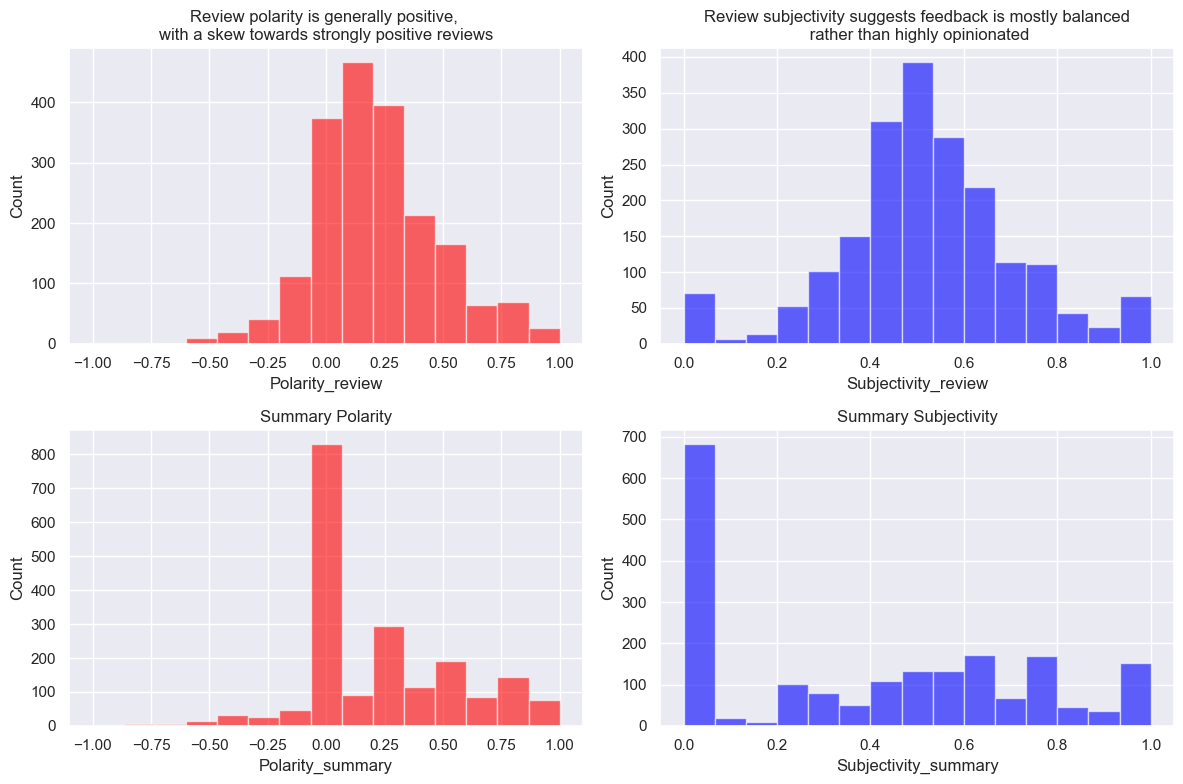

In [82]:
# Create histograms to show polarity and subjectivity for review and summary
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.set_style('white')

plots = [
    ('polarity_review', 'Review polarity is generally positive, \nwith a skew towards strongly positive reviews', 'red'),
    ('subjectivity_review', 'Review subjectivity suggests feedback is mostly balanced\n rather than highly opinionated', 'blue'),
    ('polarity_summary', 'Summary Polarity', 'red'),
    ('subjectivity_summary', 'Summary Subjectivity', 'blue')
]

for ax, (col, title, color) in zip(axes.flatten(), plots):
    ax.hist(df4[col], bins=15, color=color, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [83]:
# Show top 20 positive and negative reviews for review and summary
configs = [
    ('review', 'polarity_review', 'subjectivity_review'),
    ('summary', 'polarity_review', 'subjectivity_summary')
]

for text_col, polarity_col, subjectivity_col in configs:

    print(f'\nTop 20 negative {text_col}s')
    display(
        df4.nsmallest(20, polarity_col)[
        [text_col, polarity_col, subjectivity_col]
        ].style.set_properties(subset=[text_col], **{'width':'1200px'})
    )

    print(f'\nTop 20 positive {text_col}s')
    display(
        df4.nlargest(20, polarity_col)[
        [text_col, polarity_col, subjectivity_col]
        ].style.set_properties(subset=[text_col], **{'width':'1200px'})
    )


Top 20 negative reviews


,review,polarity_review,subjectivity_review
207,booo unles you are patient know how to measure i didnt have the patience neither did my daughter boring unless you are a craft person which i am not,-1.000000,1.000000
181,incomplete kit very disappointing,-0.780000,0.910000
1773,im sorry i just find this product to be boring and to be frank juvenile,-0.583333,0.750000
362,one of my staff will be using this game soon so i dont know how well it works as yet but after looking at the cards i believe it will be helpful in getting a conversation started regarding anger and what to do to control it,-0.550000,0.300000
116,i bought this as a christmas gift for my grandson its a sticker book so how can i go wrong with this gift,-0.500000,0.900000
226,this was a gift for my daughter i found it difficult to use,-0.500000,1.000000
229,i found the directions difficult,-0.500000,1.000000
289,instructions are complicated to follow,-0.500000,1.000000
300,difficult,-0.500000,1.000000
1501,expensive for what you get,-0.500000,0.700000



Top 20 positive reviews


,review,polarity_review,subjectivity_review
7,came in perfect condition,1.000000,1.000000
164,awesome book,1.000000,1.000000
193,awesome gift,1.000000,1.000000
489,excellent activity for teaching selfmanagement skills,1.000000,1.000000
517,perfect just what i ordered,1.000000,1.000000
583,wonderful product,1.000000,1.000000
601,delightful product,1.000000,1.000000
613,wonderful for my grandson to learn the resurrection story,1.000000,1.000000
782,perfect,1.000000,1.000000
923,awesome,1.000000,1.000000



Top 20 negative summarys


,summary,polarity_review,subjectivity_summary
207,boring unless you are a craft person which i am,-1.000000,1.000000
181,incomplete kit,-0.780000,0.000000
1773,disappointing,-0.583333,0.700000
362,anger control game,-0.550000,0.300000
116,stickers,-0.500000,0.000000
226,two stars,-0.500000,0.000000
229,three stars,-0.500000,0.000000
289,two stars,-0.500000,0.000000
300,three stars,-0.500000,0.000000
1501,two stars,-0.500000,0.000000



Top 20 positive summarys


,summary,polarity_review,subjectivity_summary
7,five stars,1.000000,0.000000
164,five stars,1.000000,0.000000
193,five stars,1.000000,0.000000
489,five stars,1.000000,0.000000
517,five stars,1.000000,0.000000
583,five stars,1.000000,0.000000
601,five stars,1.000000,0.000000
613,five stars,1.000000,0.000000
782,aquire game,1.000000,0.400000
923,five stars,1.000000,0.000000


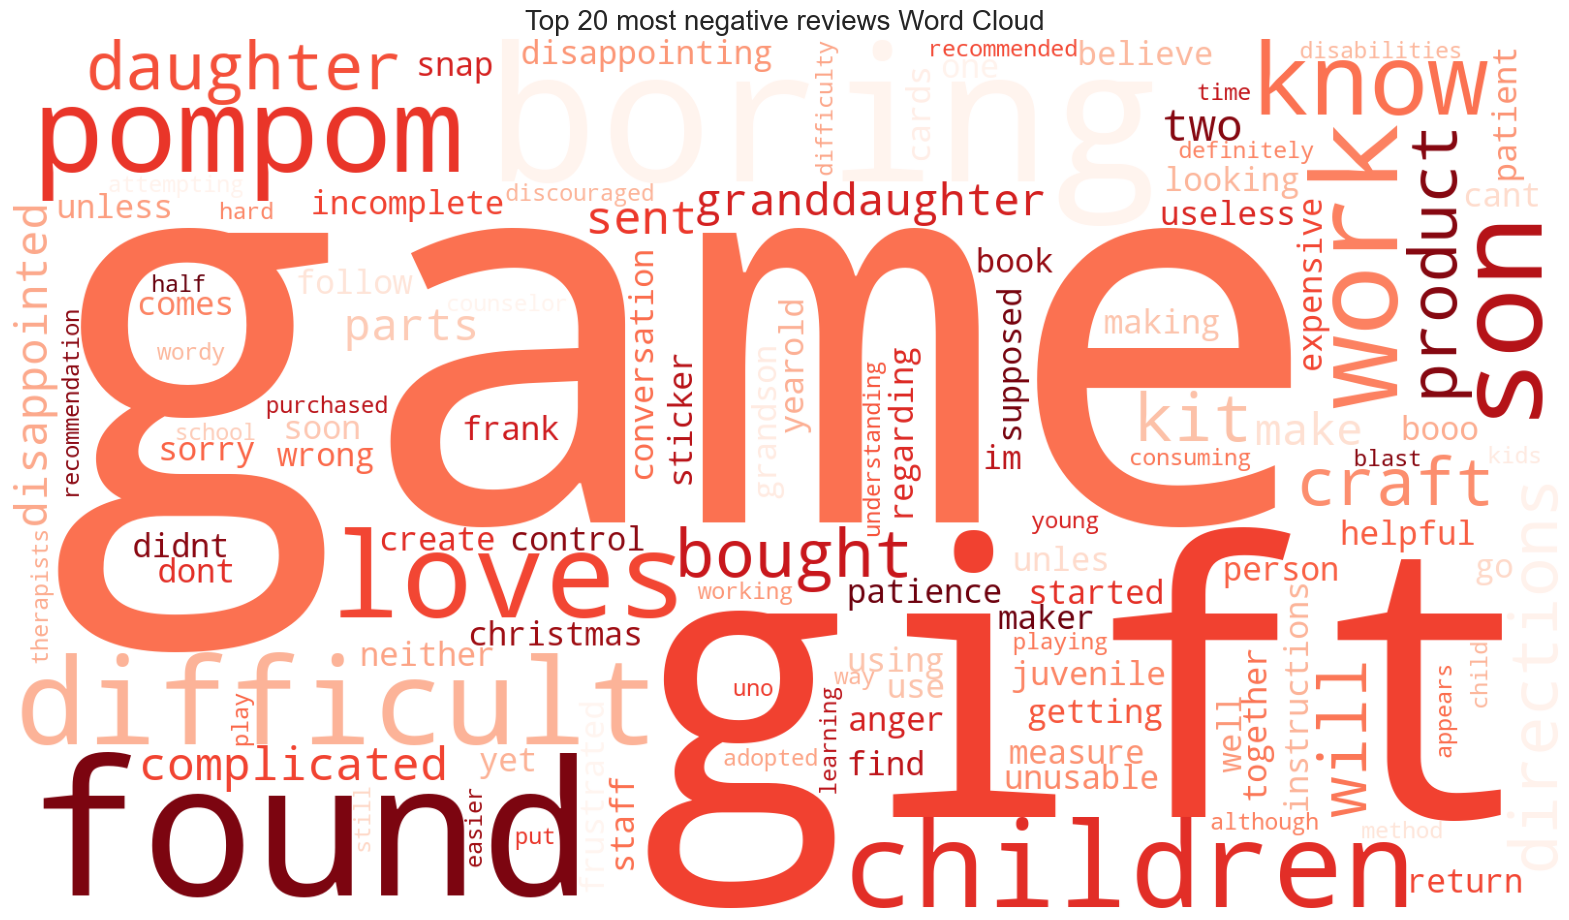

In [84]:
# Create a word cloud of the top 20 most negative reviews
negative_reviews = {
    'review':' '.join(
        df4.nsmallest(20, 'polarity_review')['review'].dropna().astype(str)
    )
}

# Configuration
wordcloud_configs = [
    {
        'label':'Top 20 most negative reviews',
        'column': negative_reviews['review'],
        'colormap':'Reds'
    }
]

sns.set(color_codes=True)

for cfg in wordcloud_configs:
    wc = WordCloud(width = 1600, height = 900, 
                background_color ='white',
                colormap = cfg['colormap'], 
                stopwords = None,
                min_font_size = 10).generate(cfg['column'])

    # Plot word cloud
    plt.figure(figsize = (16, 9), facecolor = None) 
    plt.imshow(wc) 
    plt.axis('off') 
    plt.title(f'{cfg['label']} Word Cloud', fontsize=20)
    plt.tight_layout(pad = 0) 
    plt.show()

**Insights uncovered**:
- **Word Clouds**:The word clouds generated from both the full reviews and the summaries suggest an overall positive sentiment towards Turtle games. The word cloud for summary highlighted words such as 'great', 'love', 'five stars', 'awesome' and 'fun'. This indicates a strong positive effect. In the review word clouds, many of the same positive sentiment appears. The word cloud is dominated by the word 'game'. While this does not carry much sentiment, it indicates that reviewers are focussed on the core product rather than tangential issues which is a useful validation of the dataset being on topics rather than unrelated noise.
- **Word frequency**: Positive terms such as 'great' and 'love' appear frequently, reinforcing the positive findings observed earlier. However, other words such as 'cards', 'tiles', 'kids' are also a recurring theme in customer reviews. This highlights an opportunity for further analysis as these words may recur to show key strengths to the business or weakness, which either way would be useful to explore. A quick analysis into the reviews containing the word 'cards' showed a consistent theme discussing the benefits consumers had seen for children with anger issues, a look into the reviews using the word 'tiles' showing multiple reviews discussing the low quality using cardboard. While this quick review is not sufficient to warrant business action, this demonstrates the kind of insight that can be drawn from in depth text analytics. 
- **Polarity/Subjectivity in reviews**: looking at the review-level polarity distribution, the histogram shows a roughly bell shaped curve with a slight right skew. The peak is at around 0.1-0.2 indicating reviews tend to be slightly positive rather than polarised. The right tail of the distribution is longer and denser than the left tail, suggesting there are more strongly positive reviews than strongly negative. Very few negative reviews fall below -0.5 indicating that highly negative reviews are rare. For subjectivity, the distributino is approximately normal centered around 0.5, suggesting that most reviews contain a balance of opinion and fact rather than purely emotional or objective.
- **Polarity/Subjectivity in summary**: in contrast the summary shows a slightly different picture to reviews with both subjectivity and polarity showing a substantial spike at 0. This is expected as summaries are shorter and often more neutral making sentiment harder to detect. However, polarity still shows a skew towards positive polarity mirroring the trend seen in reviews. The subjectivity scores are much more fragmented, which again reflects the difficulty in determing sentiment with less detail.
- **Top N Analysis**: the analysis of the top 20 negative reviews revealed a consistent theme in the difficulty of the games, with several reviews showing frustration around complexity and rules. This finding is especially important because it does not contradict the overall positive sentiment, but pinpoints a specific area for improvement. This insight is highly actionable and should be incorporated into product reviews and marketing communication.